In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# ---------------------------------------------------------
# 1. Generate one-dimensional toy data
# ---------------------------------------------------------

rng = np.random.default_rng(42)

n_samples = 200

# One input feature: x
x = rng.uniform(-6, 6, size=n_samples)

# True decision rule:
# Positive class = 1 if x <= -2 OR x >= 2
# Negative class = 0 if -2 < x < 2
y = ((x <= -2) | (x >= 2)).astype(int)

# Jitter is only for visualization
jitter = rng.uniform(0, 1, size=n_samples)

# scikit-learn expects X to be 2D: shape = (n_samples, n_features)
X = x.reshape(-1, 1)


(-0.05, 1.05)

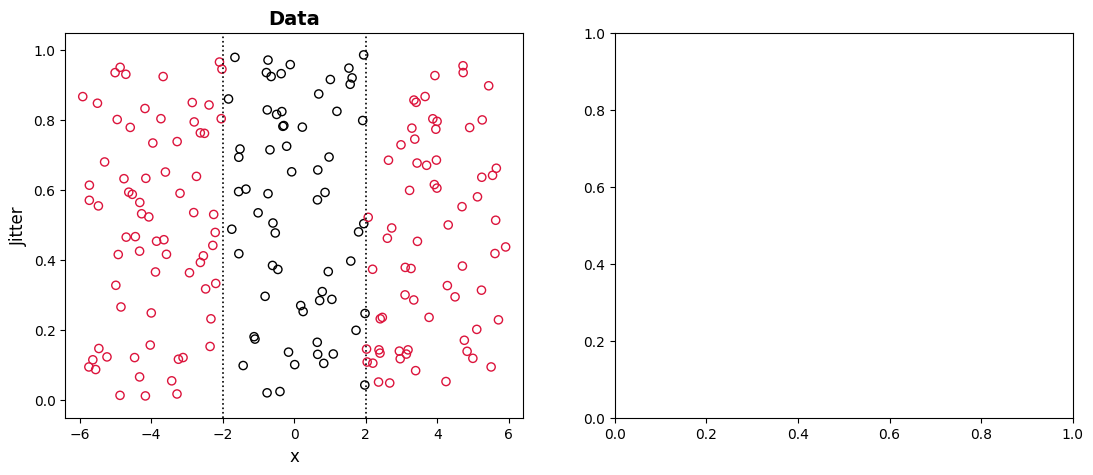

In [3]:

# ---------------------------------------------------------
# 2. Fit bagging model with 200 decision stumps
# ---------------------------------------------------------

stump = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

bagging_clf = BaggingClassifier(
    estimator=stump,
    n_estimators=200,
    bootstrap=True,
    max_samples=1.0,
    random_state=42,
    n_jobs=-1
)

bagging_clf.fit(X, y)

BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                   random_state=42),
                  n_estimators=200, n_jobs=-1, random_state=42)

In [4]:


# ---------------------------------------------------------
# 3. Create grid for plotting decision probabilities
# ---------------------------------------------------------

x_grid = np.linspace(-6, 6, 800)
X_grid = x_grid.reshape(-1, 1)

# Find the column corresponding to the positive class label 1
positive_class_index = np.where(bagging_clf.classes_ == 1)[0][0]

# Bagged probability for positive class
bagged_prob = bagging_clf.predict_proba(X_grid)[:, positive_class_index]

# Individual stump probabilities for positive class
individual_probs = []

for tree in bagging_clf.estimators_:
    tree_prob = tree.predict_proba(X_grid)[:, positive_class_index]
    individual_probs.append(tree_prob)

individual_probs = np.array(individual_probs)




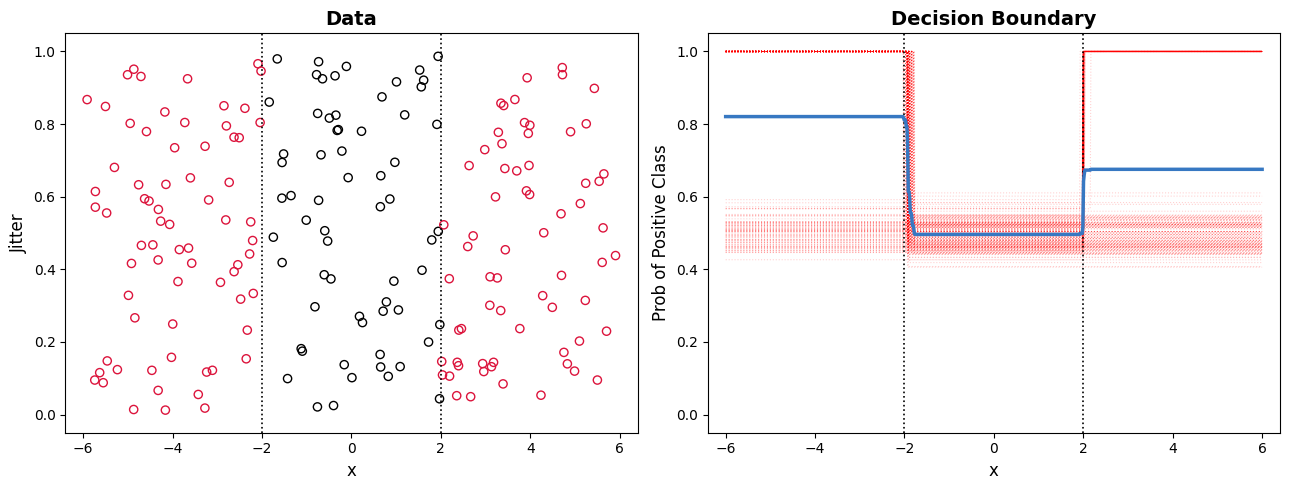

In [9]:

# ---------------------------------------------------------
# 2. Plot
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]

# Negative class: black open circles
ax.scatter(
    x[y == 0],
    jitter[y == 0],
    facecolors="none",
    edgecolors="black",
    s=35,
    label="Negative class"
)

# Positive class: red open circles
ax.scatter(
    x[y == 1],
    jitter[y == 1],
    facecolors="none",
    edgecolors="crimson",
    s=35,
    label="Positive class"
)

# True decision boundaries
ax.axvline(-2, color="black", linestyle=":", linewidth=1.2)
ax.axvline(2, color="black", linestyle=":", linewidth=1.2)

ax.set_title("Data", fontsize=14, fontweight="bold")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("Jitter", fontsize=12)
ax.set_xlim(-6.4, 6.4)
ax.set_ylim(-0.05, 1.05)

ax = axes[1]

# Plot probabilities from each of the 200 decision stumps
for prob in individual_probs:
    ax.plot(
        x_grid,
        prob,
        color="red",
        linestyle=":",
        linewidth=0.8,
        alpha=0.18
    )

# Plot true boundaries
ax.axvline(-2, color="black", linestyle=":", linewidth=1.2)
ax.axvline(2, color="black", linestyle=":", linewidth=1.2)

# Plot bagged prediction probability
ax.plot(
    x_grid,
    bagged_prob,
    color="#3778c2",
    linewidth=2.5,
    label="Bagged probability"
)

ax.set_title("Decision Boundary", fontsize=14, fontweight="bold")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("Prob of Positive Class", fontsize=12)
ax.set_xlim(-6.4, 6.4)
ax.set_ylim(-0.05, 1.05)

# Optional legend
# ax.legend(frameon=False)

plt.tight_layout()
plt.show()